In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.gridspec import GridSpec
import matplotlib.image as image
from scipy import stats
import pickle
import pandas as pd

In [2]:
# caution: path[0] is reserved for script path 
sys.path.insert(1, './utils/')

In [4]:
# from load_data import *
# from plot_functions import *
from utils_functions import *

In [8]:
filename = '../data_experiments/data_for_typing.pickle'
with open(filename, "rb") as handle:   #Pickling
    clusdict = pickle.load(handle)

periods = np.array([170,120,100,80,60])


In [12]:
# load stimulus info 

filename = f"../data_experiments/data_OSR_cells_ON_luminance.pkl"
with open(filename, "rb") as handle:   #Pickling
   cells_dict =  pickle.load(handle)



filename = f"../data_experiments/data_shift_cells_ON.pkl"
with open(filename, "rb") as handle:   #Pickling
   cells_dict2 =  pickle.load(handle)


time = cells_dict['stimulus_info']['3']['osr_time'] - cells_dict['stimulus_info']['3']['lastflashend']
time_short = np.arange(0,int(len(time)/2))*0.02  - cells_dict['stimulus_info']['3']['lastflashend']
statime = np.arange(0,1,0.025)
OSflashend = periods[3]/1000
OSflashstart = periods[3]/1000-0.04

In [13]:
len(time)

520

In [17]:
stim_osr,stimime,lfp= periodic_flashes(12,12)


stimulus = os.path.join('../data_experiments/chirp_luminance_profile.csv')
stimulus = pd.read_csv(stimulus)

stim_chirp = stimulus['luminance']
time_chirp = np.arange(0,30,0.02)
time_chirp_res = np.arange(0,30,0.1)

#stim_check 

def generate_2d_white_noise_frame(dimensions=(24, 24), seed=0):
    """ dimensions: number of checks in x and y dimensions """
    np.random.seed(seed)
    white_noise_2d_frame = np.random.choice([0, 255], size=(dimensions[0], dimensions[1]))
    return white_noise_2d_frame

check = generate_2d_white_noise_frame()


In [18]:
# indices of each cluster 
ONt  = [35,33,32,31,29,27,26,25,24,22,10,36]
ONts = [19,17,20,0,8,34,15,6,16,21]
ONs = [14,13,12,5]
ONOFF = [2,1,4,28,9,23]

In [19]:
counts_ONt = []
temp_ONt = []
exps_ONt = []
osrs_ONt = []
latencies_ONt = []

for i in ONt:
    counts_ONt.append(clusdict['counts_chirp'][i])
    temp_ONt.append(clusdict['temporal'][i])
    exps_ONt.append(clusdict['exps'][i])
    osrs_ONt.append(clusdict['counts_osr_12'][i])
    latencies_ONt.append(clusdict['latencies'][i])

counts_ONts = []
temp_ONts = []
exps_ONts = []
osrs_ONts = []
latencies_ONts = []

for i in ONts:
    counts_ONts.append(clusdict['counts_chirp'][i])
    temp_ONts.append(clusdict['temporal'][i])
    exps_ONts.append(clusdict['exps'][i])
    osrs_ONts.append(clusdict['counts_osr_12'][i])
    latencies_ONts.append(clusdict['latencies'][i])


counts_ONs = []
temp_ONs = []
osrs_ONs = []
exps_ONs = []

latencies_ONs = []

for i in ONs:
    counts_ONs.append(clusdict['counts_chirp'][i])
    temp_ONs.append(clusdict['temporal'][i])
    osrs_ONs.append(clusdict['counts_osr_12'][i])
    exps_ONs.append(clusdict['exps'][i])

    latencies_ONs.append(clusdict['latencies'][i])

counts_ONOFF = []
temp_ONOFF = []
osrs_ONOFF = []
exps_ONOFF = []

latencies_ONOFF = []

for i in ONOFF:
    counts_ONOFF.append(clusdict['counts_chirp'][i])
    temp_ONOFF.append(clusdict['temporal'][i])
    osrs_ONOFF.append(clusdict['counts_osr_12'][i])
    exps_ONOFF.append(clusdict['exps'][i])
    latencies_ONOFF.append(clusdict['latencies'][i])



nb_ONt = len(ONt)
nb_ONts = len(ONts)
nb_ONs = len(ONs)
nb_ONOFF = len(ONOFF)


In [20]:
clusdict['latencies'][i]

[array([         nan, 229.32153789, 214.18480272, 192.99337347,
        157.67432473]),
 1.14,
 0.0926479968427005]

In [21]:

lats_16 = [clusdict['latencies'][i][0][-1] for i in range(len(clusdict['latencies']))]
np.nanmin(lats_16), np.nanmax(lats_16)

(141.52847388072243, 482.60957314406795)

In [28]:
save = True
save_name = "../Figures/Figure_s1"
show = True
image_format = "png"
dpi = 300

In [29]:

#figure parameter

fontsize_legend = 20
fontsize_labels = 10
fontsize_panellabel = 30
fontsize_ticks = 20
lw = 2
lwthin = 2
ms = 60
frequencytext_position = [0.15,1.4]



colr = 'green'
colr2 = 'blue'
colr3 = 'darkorange'
colr4 = 'deeppink'
periods = np.array([170,120,100,80,60])





20211109_Thomas 260
20230525_Thomas 260
20210326_Thomas 260
20210326_Thomas 260
20230525_Thomas 260
20210326_Thomas 260
20230525_Thomas 260
20230406_Thomas 260
20230406_Thomas 260
20230406_Thomas 260
20210326_Thomas 260
20210326_Thomas 260
20210326_Thomas 260
20210326_Thomas 260
20211007_Thomas 260


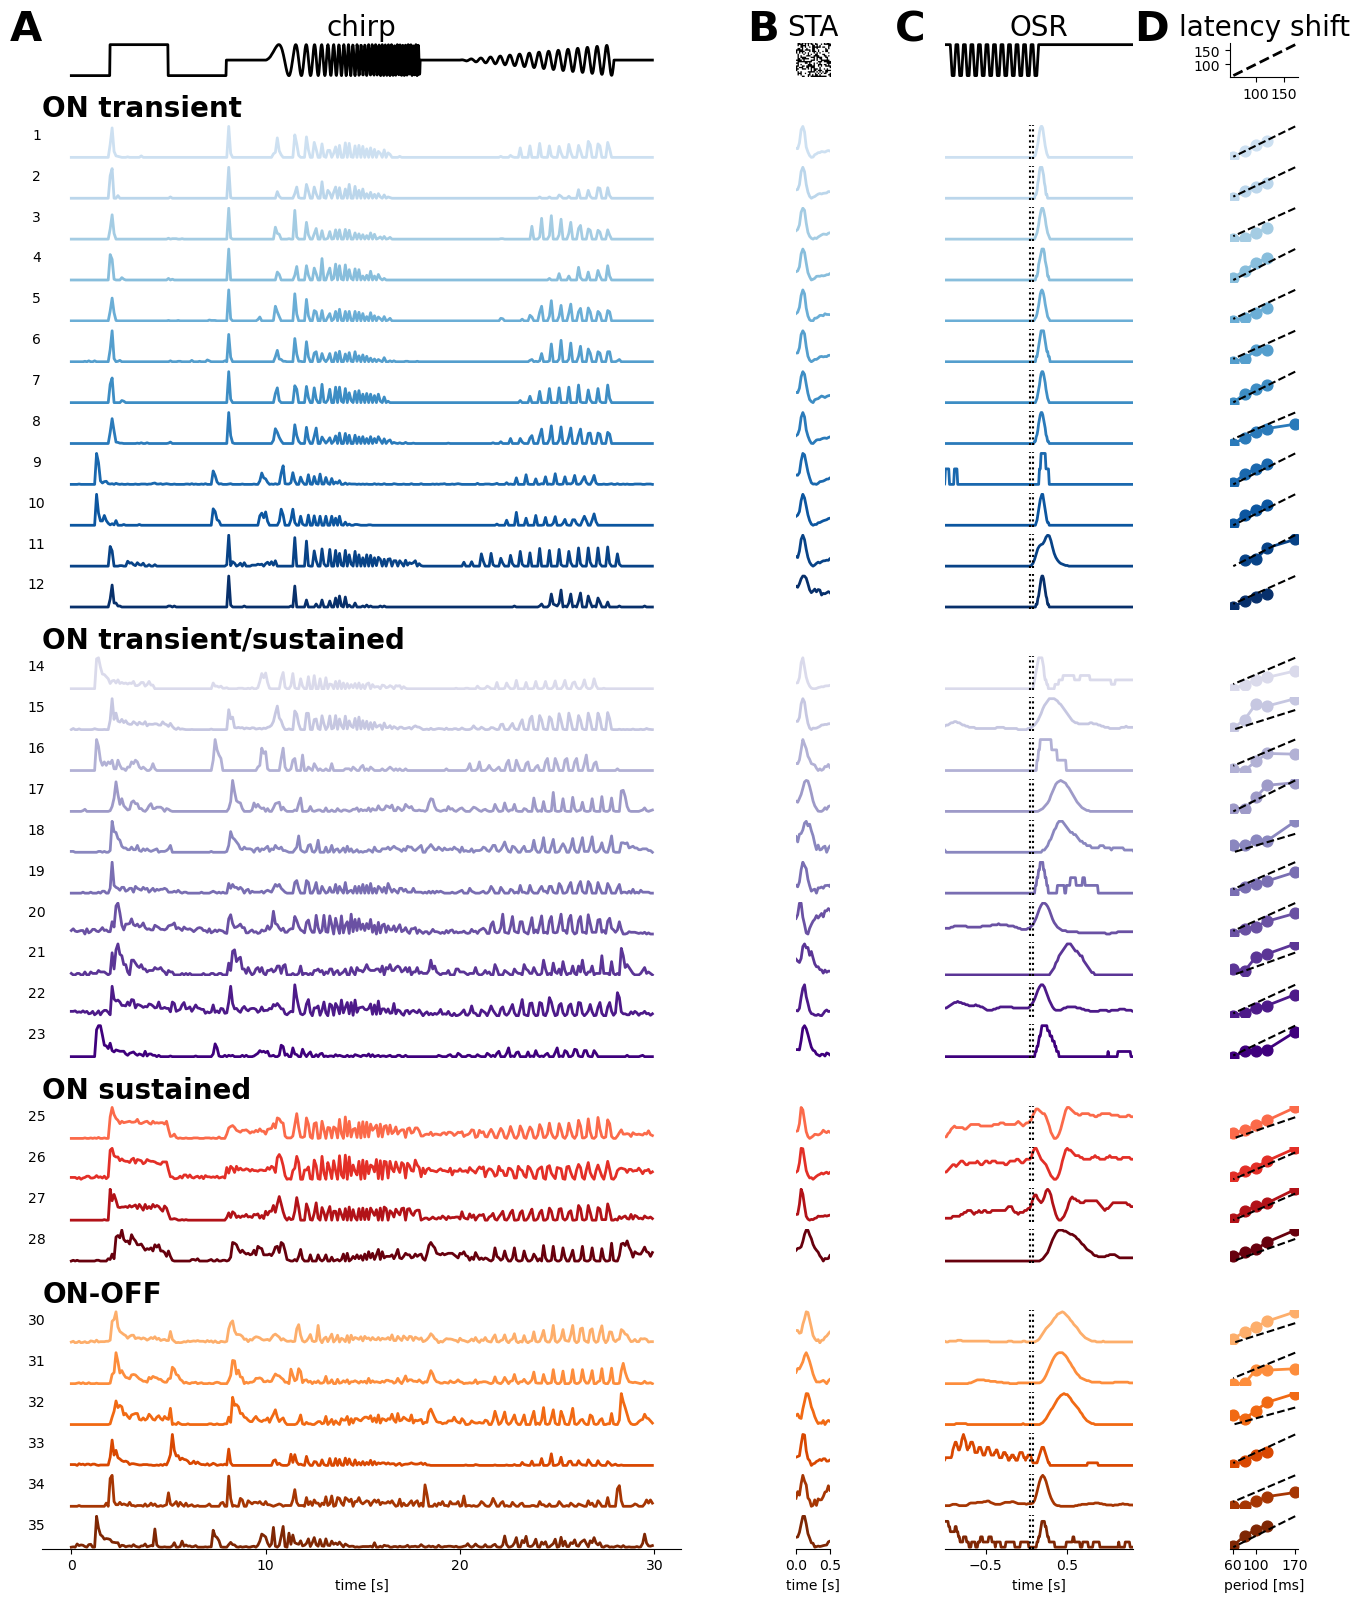

In [30]:
#initialize figure
panellabel_position = [0.0,2]

nrows = 42
ncols = 6

figsize_ratio = 3
figsize = (14,18)


fig = plt.figure(figsize=figsize)
fig.patch.set_facecolor('white')


gs = fig.add_gridspec(nrows,ncols)
#fig.tight_layout()


fig.subplots_adjust(
top= .95,
bottom= 0.0,
left=0.05,
right=0.99,
hspace=0.2,
wspace=0.2
)
osrlim = (-1,1.3)

#####################################################################################################################
# create panels
#####################################################################################################################

# header 

#chirp response
ax = fig.add_subplot(gs[0,:3],frameon = False)
ax.plot(time_chirp,stim_chirp, color = 'k', linewidth = lw)
ax.set_title('chirp', fontsize = fontsize_legend)
ax.set_xticks([])
ax.set_yticks([])

ax.text(panellabel_position[0],panellabel_position[1], 'A', transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


#sta
ax2 = fig.add_subplot(gs[0,3],frameon = False)
ax2.imshow(check, cmap='Greys')
ax2.set_title('STA', fontsize = fontsize_legend)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_box_aspect(1)



ax2.text(panellabel_position[0]-.5,panellabel_position[1], 'B', transform=ax2.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

# OSR at 12 Hz
ax2 = fig.add_subplot(gs[0,4],frameon = False)
ax2.plot(stimime-lfp,stim_osr,color = 'k', linewidth = lw)
ax2.set_xlim(-1,1)
ax2.set_title('OSR', fontsize = fontsize_legend)
ax2.set_xticks([])
ax2.set_yticks([])




ax2.text(panellabel_position[0]-.1,panellabel_position[1], 'C', transform=ax2.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


# latency scaling
ax2 = fig.add_subplot(gs[0,5])
ax2.plot(periods,slope_fun(periods,1,0), color = 'k', linestyle = '--', linewidth = lw)
ax2.set_title('latency shift', fontsize = fontsize_legend)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_box_aspect(1/2)




ax2.text(panellabel_position[0]-.9,panellabel_position[1], 'D', transform=ax2.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


### ON transient
rowcounter = 1

nb = nb_ONt
counts = counts_ONt
temp = temp_ONt
osrs = osrs_ONt
latencies = latencies_ONt
cmap =  plt.get_cmap('Blues',nb+3)
for i in range(nb):
    rowcounter = rowcounter+1
    
    #chirp response
    ax = fig.add_subplot(gs[rowcounter,:3],frameon = False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.plot(time_chirp_res,counts[i],color = cmap(i+3), linewidth = lw) 
    ax.set_ylabel(f'{rowcounter-1}', fontsize = fontsize_labels, rotation=0, loc = 'center')

    if i == 0:
        ax.set_title('ON transient', fontsize = fontsize_legend, fontweight = 'bold', loc ='left')
    #sta
    ax2 = fig.add_subplot(gs[rowcounter,3],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(statime,np.flip(temp[i]), color = cmap(i+3), linewidth = lw)
    ax2.set_xlim(0,0.5)
    ax2.set_box_aspect(1)

    # OSR at 12 Hz
    ax2 = fig.add_subplot(gs[rowcounter,4],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlim(osrlim)

    try:
        ax2.plot(time,osrs[i],color = cmap(i+3), linewidth = lw)
        ax2.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax2.axvline(OSflashend, linestyle = ':', color = 'k')
    except:
        ax2.plot(time_short,osrs[i],color = cmap(i+3), linewidth = lw)
        print(exps_ONt[i], len(osrs[i]))
        ax2.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax2.axvline(OSflashend, linestyle = ':', color = 'k')


    # latency scaling
    ax2 = fig.add_subplot(gs[rowcounter,5],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(periods, latencies[i][0], color = cmap(i+3), linewidth = lw)
    ax2.scatter(periods, latencies[i][0],color = cmap(i+3), s = ms)
    ax2.plot(periods, slope_fun(periods,1,latencies[i][2]*1000), linestyle = '--', color = 'k')
    ax2.set_box_aspect(1/2)
    #ax2.set_ylim(100,300)

### ON transient-sustained
rowcounter = rowcounter+1

nb = nb_ONts
counts = counts_ONts
temp = temp_ONts
osrs = osrs_ONts
latencies = latencies_ONts
cmap =  plt.get_cmap('Purples',nb+3)
for i in range(nb):
    rowcounter = rowcounter+1
    
    #chirp response
    ax = fig.add_subplot(gs[rowcounter,:3],frameon = False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.plot(time_chirp_res,counts[i],color = cmap(i+3), linewidth = lw) 
    ax.set_ylabel(f'{rowcounter-1}', fontsize = fontsize_labels, rotation=0, loc = 'center')

    if i == 0:
        ax.set_title('ON transient/sustained', fontsize = fontsize_legend, fontweight = 'bold', loc ='left')
    #sta
    ax2 = fig.add_subplot(gs[rowcounter,3],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(statime,np.flip(temp[i]),color = cmap(i+3), linewidth = lw)
    ax2.set_xlim(0,0.5)
    ax2.set_box_aspect(1)

    # OSR at 12 Hz
    ax2 = fig.add_subplot(gs[rowcounter,4],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlim(osrlim)

    try:
        ax2.plot(time,osrs[i],color = cmap(i+3), linewidth = lw)
        ax2.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax2.axvline(OSflashend, linestyle = ':', color = 'k')
    except:
        ax2.plot(time_short,osrs[i],color = cmap(i+3), linewidth = lw)
        print(exps_ONts[i], len(osrs[i]))
        ax2.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax2.axvline(OSflashend, linestyle = ':', color = 'k')


    # latency scaling
    ax2 = fig.add_subplot(gs[rowcounter,5],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(periods, latencies[i][0], color = cmap(i+3), linewidth = lw)
    ax2.scatter(periods, latencies[i][0],color = cmap(i+3), s = ms)
    ax2.plot(periods, slope_fun(periods,1,latencies[i][2]*1000), linestyle = '--', color = 'k')
    ax2.set_box_aspect(1/2)


### ON sustained
rowcounter = rowcounter+1

nb = nb_ONs
counts = counts_ONs
temp = temp_ONs
osrs = osrs_ONs
latencies = latencies_ONs
cmap =  plt.get_cmap('Reds',nb+3)
for i in range(nb):
    rowcounter = rowcounter+1
    
    #chirp response
    ax = fig.add_subplot(gs[rowcounter,:3],frameon = False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.plot(time_chirp_res,counts[i],color = cmap(i+3), linewidth = lw) 
    ax.set_ylabel(f'{rowcounter-1}', fontsize = fontsize_labels, rotation=0, loc = 'center')

    if i == 0:
        ax.set_title('ON sustained', fontsize = fontsize_legend, fontweight = 'bold', loc ='left')
    #sta
    ax2 = fig.add_subplot(gs[rowcounter,3],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(statime,np.flip(temp[i]),color = cmap(i+3), linewidth = lw)
    ax2.set_xlim(0,0.5)
    ax2.set_box_aspect(1)

    # OSR at 12 Hz
    ax2 = fig.add_subplot(gs[rowcounter,4],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlim(osrlim)

    try:
        ax2.plot(time,osrs[i],color = cmap(i+3), linewidth = lw)
        ax2.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax2.axvline(OSflashend, linestyle = ':', color = 'k')
    except:
        ax2.plot(time_short,osrs[i],color = cmap(i+3), linewidth = lw)
        print(exps_ONs[i], len(osrs[i]))
        ax2.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax2.axvline(OSflashend, linestyle = ':', color = 'k')


    # latency scaling
    ax2 = fig.add_subplot(gs[rowcounter,5],frameon = False)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(periods, latencies[i][0], color = cmap(i+3), linewidth = lw)
    ax2.scatter(periods, latencies[i][0],color = cmap(i+3), s = ms)
    ax2.plot(periods, slope_fun(periods,1,latencies[i][2]*1000), linestyle = '--', color = 'k')
    ax2.set_box_aspect(1/2)


### ON-OFF
rowcounter = rowcounter+1


nb = nb_ONOFF
counts = counts_ONOFF
temp = temp_ONOFF
osrs = osrs_ONOFF
latencies = latencies_ONOFF
cmap =  plt.get_cmap('Oranges',nb+3)
for i in range(nb):
    rowcounter = rowcounter+1
    
    #chirp response
    ax = fig.add_subplot(gs[rowcounter,:3])

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.plot(time_chirp_res,counts[i],color = cmap(i+3), linewidth = lw) 
    ax.set_ylabel(f'{rowcounter-1}', fontsize = fontsize_labels, rotation=0, loc = 'center')

    if i == 0:
        ax.set_title('ON-OFF', fontsize = fontsize_legend, fontweight = 'bold', loc ='left')
    #sta
    ax2 = fig.add_subplot(gs[rowcounter,3])
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.plot(statime,np.flip(temp[i]),color = cmap(i+3), linewidth = lw)
    ax2.set_xlim(0,0.5)
    ax2.set_box_aspect(1)

    ax2.spines['top'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)


    # OSR at 12 Hz
    ax3 = fig.add_subplot(gs[rowcounter,4])
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.set_xlim(osrlim)



    ax3.spines['top'].set_visible(False)
    ax3.spines['bottom'].set_visible(False)
    ax3.spines['left'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    try:
        ax3.plot(time,osrs[i],color = cmap(i+3), linewidth = lw)
        ax3.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax3.axvline(OSflashend, linestyle = ':', color = 'k')
    except:
        ax3.plot(time_short,osrs[i],color = cmap(i+3), linewidth = lw)
        print(exps_ONOFF[i], len(osrs[i]))
        ax3.axvline(OSflashstart, linestyle = ':', color = 'k')
        ax3.axvline(OSflashend, linestyle = ':', color = 'k')


    # latency scaling
    ax4 = fig.add_subplot(gs[rowcounter,5])
    ax4.set_xticks([])
    ax4.set_yticks([])


    ax4.spines['top'].set_visible(False)
    ax4.spines['bottom'].set_visible(False)
    ax4.spines['left'].set_visible(False)
    ax4.spines['right'].set_visible(False)


    ax4.plot(periods, latencies[i][0], color = cmap(i+3), linewidth = lw)
    ax4.scatter(periods, latencies[i][0],color = cmap(i+3), s = ms)
    ax4.plot(periods, slope_fun(periods,1,latencies[i][2]*1000), linestyle = '--', color = 'k')
    ax4.set_box_aspect(1/2)



ax.spines['bottom'].set_visible(True)
#ax.locator_params(axis='x', nbins=5)
ax.set_xticks([0,10,20,30])
ax.set_xlabel('time [s]')

ax2.spines['bottom'].set_visible(True)
ax2.locator_params(axis='x', nbins=2)
ax2.set_xticks([0,.5])
ax2.set_xlabel('time [s]')

ax3.spines['bottom'].set_visible(True)
ax3.locator_params(axis='x', nbins=3)
ax3.set_xticks([-.5,.5])
ax3.set_xlabel('time [s]')


ax4.spines['bottom'].set_visible(True)
ax4.locator_params(axis='x', nbins=5)
ax4.set_xticks([60,100,170])
ax4.set_xlabel('period [ms]')




#save
if save:
    plt.savefig("{}.{}".format(save_name, image_format), dpi=dpi)
